https://drive.google.com/file/d/1H4BtzE_ilgNCkOWuPAB2Nck_ugjMFT_E/view?usp=sharing

In [2]:
#library(foreign)
# library("devtools")
# devtools::install_github("sachaepskamp/bootnet")
#library(bootnet)
# devtools::install_github("sachaepskamp/qgraph")
library(qgraph)
# devtools::install_github("jmbh/mgm")
#library(mgm)

ERROR: Error in library(bootnet): there is no package called 'bootnet'


In [3]:
install.packages("bootnet", repos="http://cran.rstudio.com/", dependencies=TRUE, type="source")

also installing the dependencies 'labelled', 'broom.helpers', 'patchwork', 'rbibutils', 'ggstats', 'statnet.common', 'ppcor', 'Rdpack', 'reshape', 'GGally', 'glassoFast', 'network', 'mathjaxr', 'sna', 'pROC', 'survey', 'mgm', 'NetworkToolbox', 'GGMncv', 'BDgraph', 'relaimpo', 'psychTools'


Warning message in install.packages("bootnet", repos = "http://cran.rstudio.com/", :
"installation of package 'rbibutils' had non-zero exit status"
Warning message in install.packages("bootnet", repos = "http://cran.rstudio.com/", :
"installation of package 'statnet.common' had non-zero exit status"
Warning message in install.packages("bootnet", repos = "http://cran.rstudio.com/", :
"installation of package 'glassoFast' had non-zero exit status"
Warning message in install.packages("bootnet", repos = "http://cran.rstudio.com/", :
"installation of package 'mathjaxr' had non-zero exit status"
Warning message in install.packages("bootnet", repos = "http://cran.rstudio.com/", :
"installation of package '

In [4]:
library(bootnet)

Loading required package: ggplot2

This is bootnet 1.6

For questions and issues, please see github.com/SachaEpskamp/bootnet.



In [6]:
install.packages("haven")
library("haven")

package 'haven' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'haven'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\Nehyba\miniconda3\envs\myenv\Lib\R\library\00LOCK\haven\libs\x64\haven.dll to C:\Users\Nehyba\miniconda3\envs\myenv\Lib\R\library\haven\libs\x64\haven.dll: Permission denied"
Warning message:
"restored 'haven'"



The downloaded binary packages are in
	C:\Users\Nehyba\AppData\Local\Temp\RtmpaeP2lH\downloaded_packages


In [8]:
getwd()

[1] "C:/Users/Nehyba/Documents/R network"

In [10]:
data_full <-read.csv("../../data/raw/justice_2324.csv", sep = ";")
#data_full <-read.spss("GGM/PTSD_data_V1.sav", to.data.frame=TRUE)



In [11]:
class(data_full)

[1] "data.frame"

In [ ]:
# Create data frame of variables that we need for analysis:
# age, gender, all 20 symptoms (_MONTH extension), Sum_GAD2, Sum_PHQ2, Passive_SI_FINAL, Active_SI_FINAL, PCS, MCS, QualityofLife_SUM)
#data<-as.data.frame(data_full[,c(2:3,11:37)]) # data for analysis
#data <- subset(data, select=c(Q28_01_MONTH:QualityofLife_SUM, PPAGE, PPGENDER)) #put covariates last
#data[, 29]<-ifelse(data$PPGENDER=='Male',1,2) # 1 is male; 2 is female
#data<-data[,-c(23,27)] # Remove SI_passive & QoL, we decided later we don't want them
#data_ptsd<-as.data.frame(data[,c(1:20)]) # PTSD items only

In [12]:
install.packages("polycor")
library(polycor)

package 'polycor' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Nehyba\AppData\Local\Temp\RtmpaeP2lH\downloaded_packages


In [13]:
#Polychorické s 26 proměnými
# ordinal version, with 7 categories
data_full_o <- as.data.frame( lapply(data_full, cut, 7, labels=FALSE) )



In [14]:
### A. Make correlation matrix
data_ptsd.cor<-cor_auto(data_full) #only ptsd symptoms
data.cor<-cor_auto(data_full) #data including covariates

Variables detected as ordinal: X1Procedurální; X2Procedurální; X3Rovnost; X4Potřeby; X5Potřeby; X6Procedurální; X7Procedurální; X8Procedurální; X9Potřeby; X10Rovnost; X11Potřeby; X12Zásluhy; X13Zásluhy; X14Rovnost; X15Rovnost; X16Rovnost; X17Potřeby; X18Potřeby; X19Zásluhy; X20Zásluhy; X21Zásluhy; X22Rovnost; X23Procedurální; X24Procedurální; X25Zásluhy; X26Procedurální

Variables detected as ordinal: X1Procedurální; X2Procedurální; X3Rovnost; X4Potřeby; X5Potřeby; X6Procedurální; X7Procedurální; X8Procedurální; X9Potřeby; X10Rovnost; X11Potřeby; X12Zásluhy; X13Zásluhy; X14Rovnost; X15Rovnost; X16Rovnost; X17Potřeby; X18Potřeby; X19Zásluhy; X20Zásluhy; X21Zásluhy; X22Rovnost; X23Procedurální; X24Procedurální; X25Zásluhy; X26Procedurální



In [15]:
names<-c("1Pr","2Pr","3R","4Po","5Po","6Pr","7Pr","8Pr","9Po","10R","11Po","12Z","13Z","14R","15R","16R","17Po","18Po","19Z","X20Z","21Z","X22R","23Pr","24Pr","25Z","26Pr")
gr3 <- list("Procedurální"=c(1,2,6,7,8,23,24,26), "Rovnost"=c(3,10,14,15,16,22), "Potřeby"=c(4,5,9,11,17,18),"Zásluhy"=c(12,13,19,20,21,25))
longnames <- c("X1Procedurální","X2Procedurální","X3Rovnost","X4Potřeby","X5Potřeby","X6Procedurální","X7Procedurální","X8Procedurální","X9Potřeby","X10Rovnost","X11Potřeby","X12Zásluhy","X13Zásluhy","X14Rovnost","X15Rovnost","X16Potřeby","X17Rovnost","X18Potřeby","X19Zásluhy","X20Zásluhy","X21Zásluhy","X22Rovnost","X23Procedurální","X24Procedurální","X25Zásluhy","X26Procedurální")

# bey polo6kz 12 zasluhy
#zas <- data.frame(j_datafin2[,c(20,18,12,19)]) #zasluhy
#pro <- data.frame(j_datafin2[,c(1,2,8,7,22,6,25,0,23)]) #procedural
#rov <- data.frame(j_datafin2[,c(13,14,3,10,16,21)])  #rovnost
#pot <- data.frame(j_datafin2[,c(9,17,4,5,15,11)]) #potreby


In [ ]:
### B. Create names object & group object for graph
#names<-c("B1","B2", "B3", "B4", "B5", "C1", "C2", "D1", "D2", "D3", "D4", "D5", "D6", "D7", "E1", "E2", "E3", "E4", "E5", "E6")
#names1<-c("B1","B2", "B3", "B4", "B5", "C1", "C2", "D1", "D2", "D3", "D4", "D5", "D6", "D7", "E1", "E2", "E3", "E4", "E5", "E6", "Anx", "Dep", "SI", "PFunc", "Mfunc", "Age", "Sex")
#longnames <- c("Intrusive thoughts", "Nightmares", "Flashbacks", "Emotional cue reactivity", "Physiological cue reactivity", "Avoidance of thoughts", "Avoidance of reminders", "Trauma-related amnesia", "Negative beliefs", "Blame of self or others", "Negative trauma-related emotions", "Loss of interest", "Detachment", "Restricted affect", "Irritability/anger", "Self-destructive/reckless behavior", "Hypervigilance", "Exaggerated startle response", "Difficulty concentrating", "Sleep disturbance")
#longnames1 <- c("Intrusive thoughts", "Nightmares", "Flashbacks", "Emotional cue reactivity", "Physiological cue reactivity", "Avoidance of thoughts", "Avoidance of reminders", "Trauma-related amnesia", "Negative beliefs", "Blame of self or others", "Negative trauma-related emotions", "Loss of interest", "Detachment", "Restricted affect", "Irritability/anger", "Self-destructive/reckless behavior", "Hypervigilance", "Exaggerated startle response", "Difficulty concentrating", "Sleep disturbance", "Anxiety", "Depression", "Suicidal ideation", "Physical functioning", "Mental functioning", "Age", "Sex")

#gr1 <- list(c(21:27), c(1:20))                         #first covariates, second group ptsd symptoms
#gr2 <- list(c(21:27), c(1:5), c(6:7),c(8:14),c(15:20)) #first covariates, then PTSD symptoms categories B C D E

#gr3 <- list("Procedurální"=c(1,2,6,7,8,23,24,26), "Rovnost"=c(3,10,14,15,17,22), "Potřeby"=c(4,5,9,11,16,18),"Zásluhy"=c(12,13,19,20,21,25)) #PTSD symptoms categories B C D E

#gr4 <- list("Intrusions"=c(1:5), "Avoidance"=c(6:7), "Cognition & mood alterations"=c(8:14),"Arousal & reactivity alterations"=c(15:20), "Clinical covariates"=c(21:27))



In [16]:
#Demographics
mean(data$PPAGE)                      #54.97285
sd(data$PPAGE)                        #14.75371
range(data$PPAGE)                     #21-89

mean(data$PPGENDER)                   #1.171946
mean(data_full$SUM_LIFETIME_TRAUMAS)  # 5.954751
sd(data_full$SUM_LIFETIME_TRAUMAS)    #3.207624
range(data_full$SUM_LIFETIME_TRAUMAS) #1-15


ERROR: Error in data$PPAGE: object of type 'closure' is not subsettable


Warning message in abbreviate(colnames(input), 3):
"abbreviate used with non-ASCII chars"


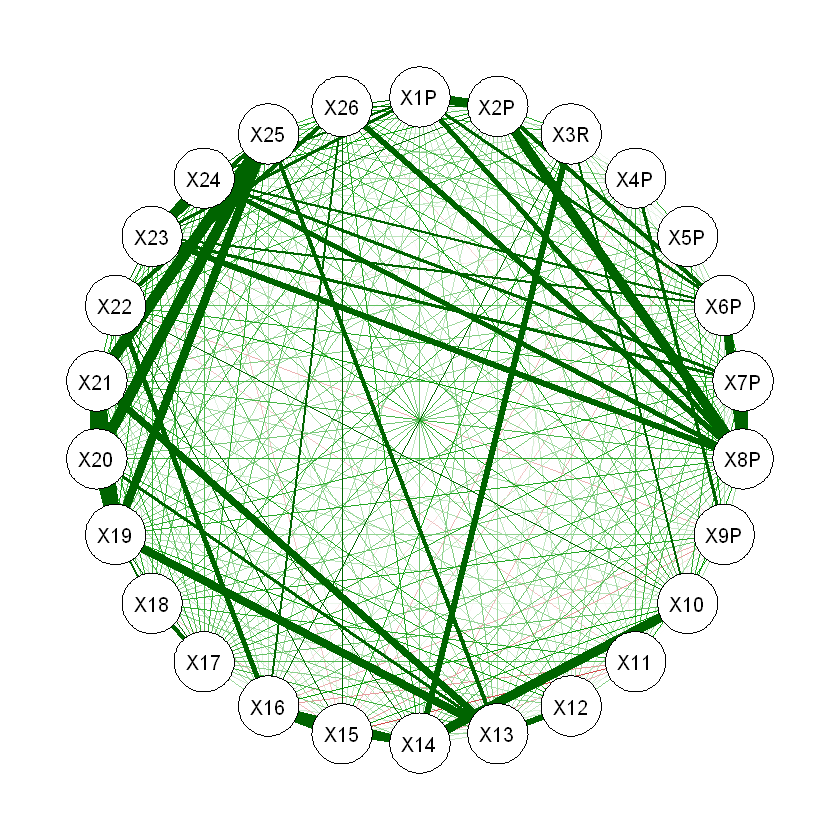

In [17]:
qgraph(data_ptsd.cor)

null device 
          1

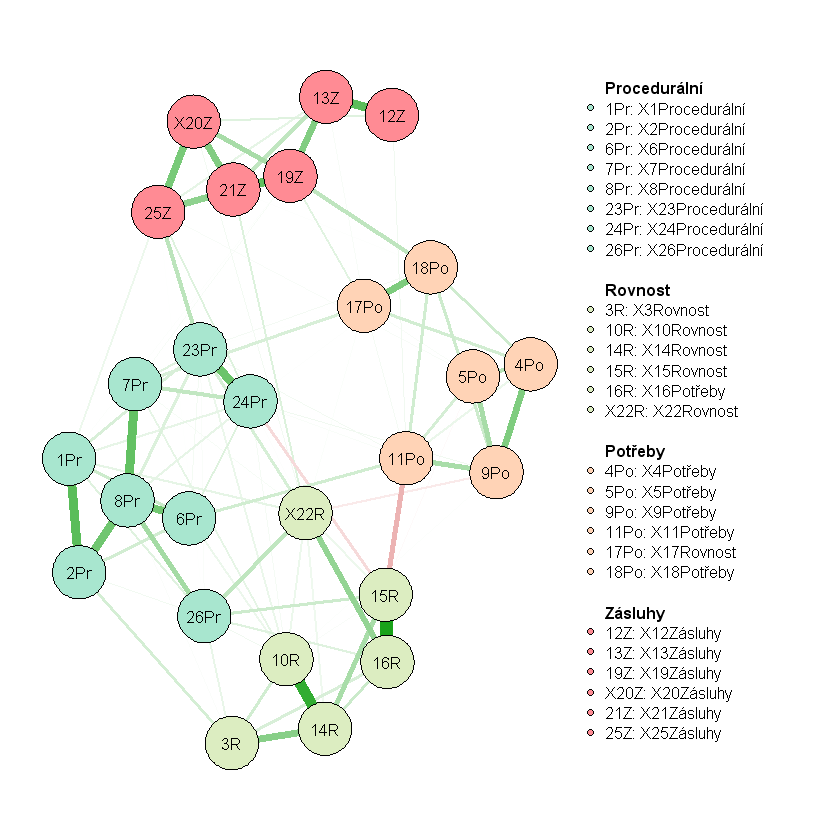

In [18]:
# ---------- ---------------------------------------------
# ---------------------------------------------------------------------------------------

graph_ptsd.m <-EBICglasso(data_ptsd.cor, n = nrow(data_full))

### A. Figure 1
# pdf("GGM/Fig.pdf", width=9, height=7)
graph_ptsd.g<-qgraph(data_ptsd.cor, labels=names, graph="glasso", layout="spring",
                     vsize=6, cut=0, maximum=.45, sampleSize = nrow(data_full),
                     border.width=1.5, border.color="black", minimum=.03,
                     groups=gr3, color=c('#a8e6cf', '#dcedc1', '#ffd3b6', '#ff8b94'),
                     nodeNames = longnames,legend.cex=.4)
dev.off()

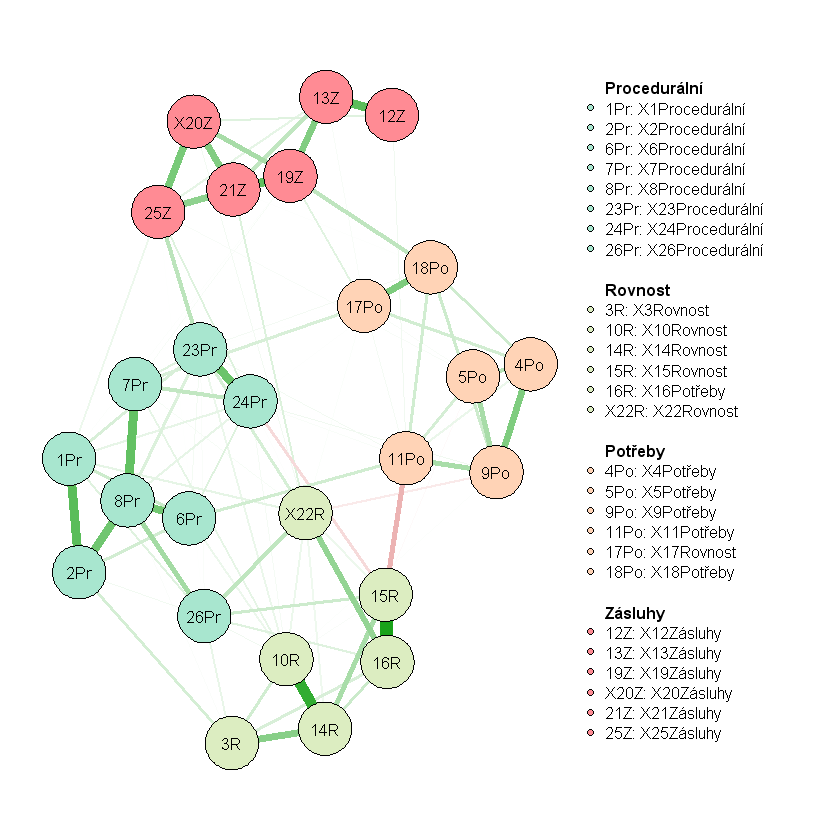

In [19]:
plot(graph_ptsd.g)

null device 
          1

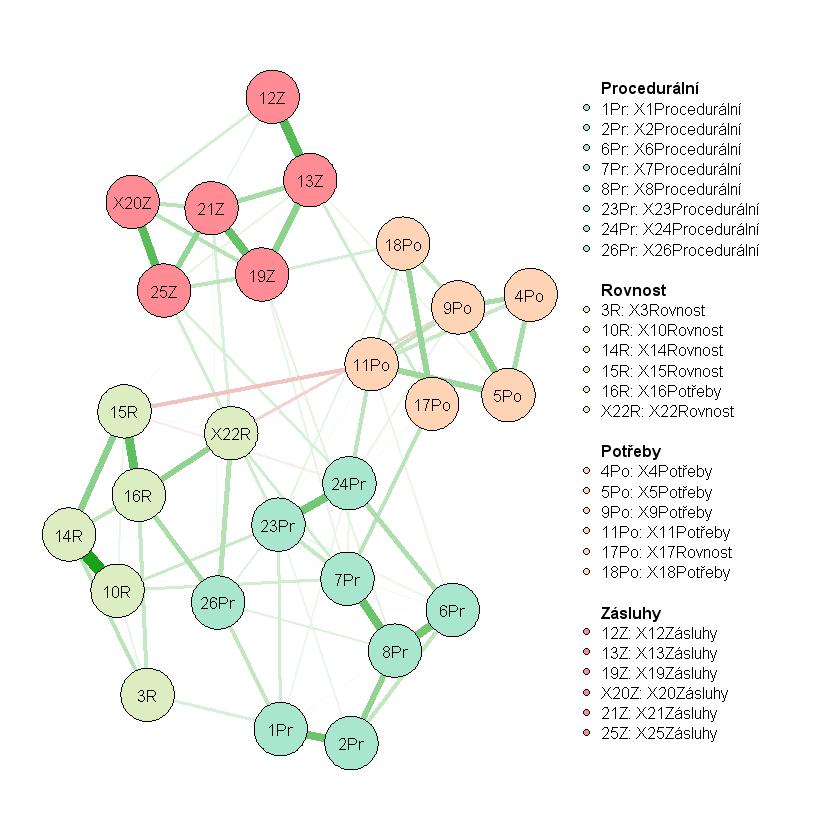

In [ ]:
graph_ptsd.g<-qgraph(data_ptsd.cor, labels=names, graph="glasso", layout="spring",
                     vsize=6, cut=0, maximum=.45, sampleSize = nrow(data_full),
                     border.width=1.5, border.color="black", minimum=.03,
                     groups=gr3, color=c('#a8e6cf', '#dcedc1', '#ffd3b6', '#ff8b94'),
                     nodeNames = longnames,legend.cex=.4)
dev.off()

# JIné řešení za pomocí:

řešení za pomocí: http://psychonetrics.org/files/PNAWS2020lecture.html

In [20]:
library("psychonetrics")

This is psychonetrics 0.13! For questions, issues, and bug reports, please see github.com/SachaEpskamp/psychonetrics.


Attaching package: 'psychonetrics'


The following object is masked from 'package:graphics':

    identify




In [21]:
obsvars <- c("X1Procedurální","X2Procedurální","X3Rovnost","X4Potřeby","X5Potřeby","X6Procedurální","X7Procedurální","X8Procedurální","X9Potřeby","X10Rovnost","X11Potřeby","X12Zásluhy","X13Zásluhy","X14Rovnost","X15Rovnost","X16Rovnost","X17Potřeby","X18Potřeby","X19Zásluhy","X20Zásluhy","X21Zásluhy","X22Rovnost","X23Procedurální","X24Procedurální","X25Zásluhy","X26Procedurální")

In [ ]:
obsvars

[1] "X1Procedurální"  "X2Procedurální"  "X3Rovnost"       "X4Potřeby"      
 [5] "X5Potřeby"       "X6Procedurální"  "X7Procedurální"  "X8Procedurální" 
 [9] "X9Potřeby"       "X10Rovnost"      "X11Potřeby"      "X12Zásluhy"     
[13] "X13Zásluhy"      "X14Rovnost"      "X15Rovnost"      "X16Rovnost"     
[17] "X17Potřeby"      "X18Potřeby"      "X19Zásluhy"      "X20Zásluhy"     
[21] "X21Zásluhy"      "X22Rovnost"      "X23Procedurální" "X24Procedurální"
[25] "X25Zásluhy"      "X26Procedurální"

In [22]:
head(data_full)

,X1Procedurální,X2Procedurální,X3Rovnost,X4Potřeby,X5Potřeby,X6Procedurální,X7Procedurální,X8Procedurální,X9Potřeby,X10Rovnost,⋯,X17Potřeby,X18Potřeby,X19Zásluhy,X20Zásluhy,X21Zásluhy,X22Rovnost,X23Procedurální,X24Procedurální,X25Zásluhy,X26Procedurální
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,7,6,7,7,7,5,7,6,5,7,⋯,7,5,5,6,6,5,7,6,7,7
2,7,7,6,4,5,7,7,7,4,7,⋯,7,5,7,6,6,7,7,7,6,7
3,5,5,2,4,4,4,5,6,4,4,⋯,5,5,5,5,6,4,6,7,4,4
4,7,6,4,3,5,4,7,7,2,4,⋯,6,5,7,7,6,7,4,5,7,5
5,5,6,3,3,4,7,7,7,5,5,⋯,5,5,6,6,7,4,5,5,7,7
6,6,6,5,7,6,6,7,7,5,7,⋯,7,7,7,7,7,3,6,6,7,4


In [23]:
library(dplyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [24]:
### Slide 33 ###
# Form GGM model:
ggm1 <- ggm(data_full, vars = obsvars)

# Run model and estimate structure:
ggm1 <- ggm1 %>% runmodel %>%
  prune(adjust = "fdr", alpha = 0.01) %>%
  stepup(criterion = "bic", alpha = 0.05)

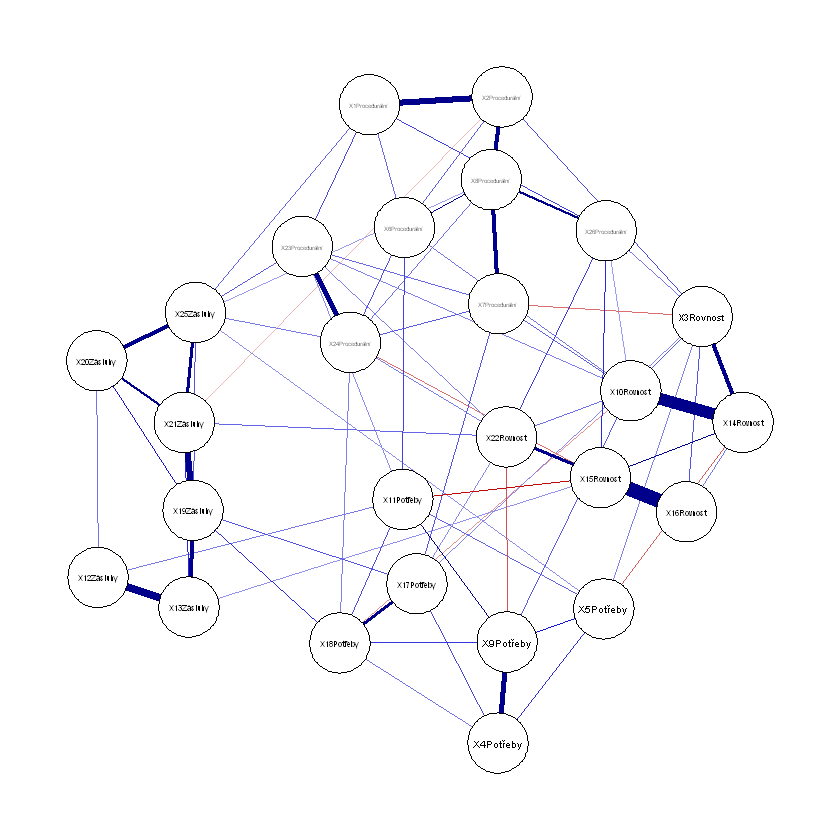

In [25]:
# Obtain network:
net1 <- getmatrix(ggm1, "omega")

qgraph(net1,
       layout = "spring",
       theme = "colorblind",
       labels = obsvars)

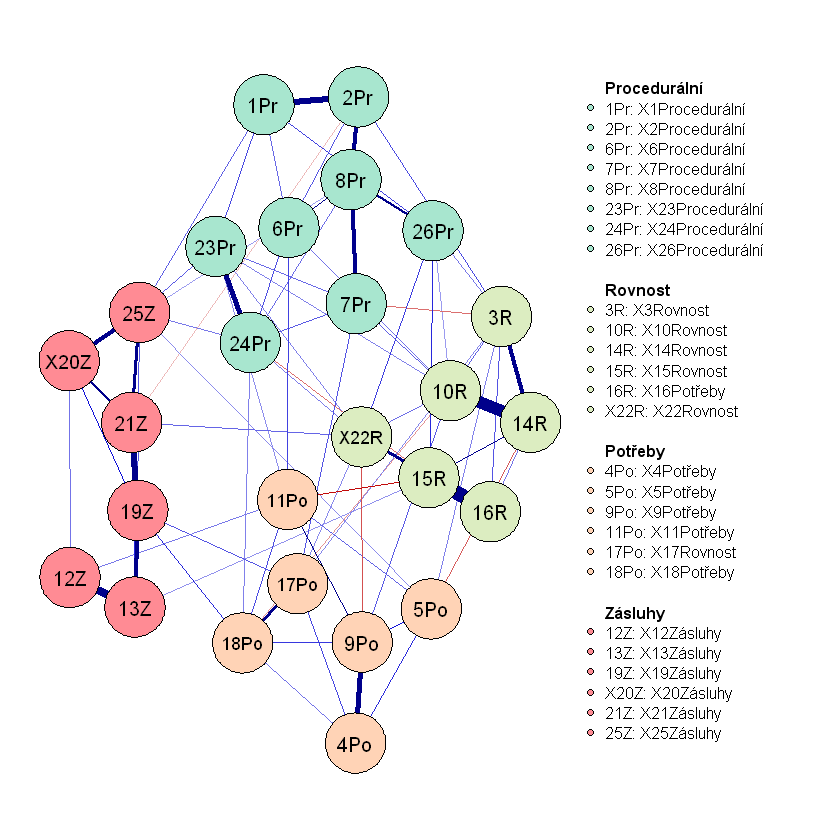

In [26]:
# Plot:

# Plot:
qgraph(net1,
       labels=names, layout = "spring",
       theme = "colorblind", groups=gr3, color=c('#a8e6cf', '#dcedc1', '#ffd3b6', '#ff8b94'), nodeNames = longnames,legend.cex=.4)

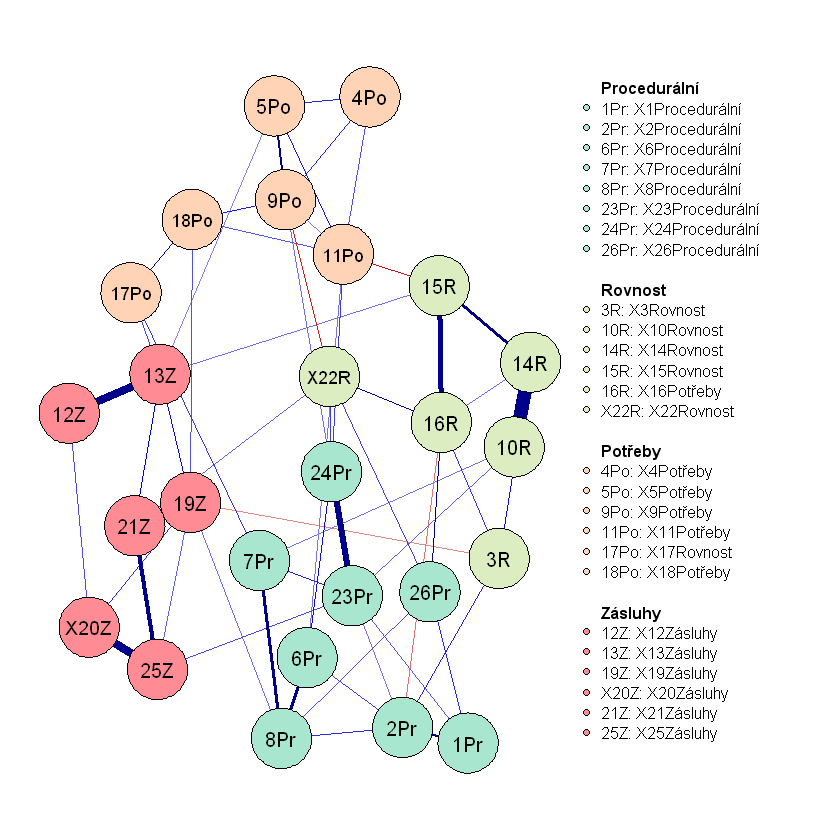

In [ ]:
# Plot:

# Plot:
qgraph(net1,
       labels=names, layout = "spring",
       theme = "colorblind", groups=gr3, color=c('#a8e6cf', '#dcedc1', '#ffd3b6', '#ff8b94'), nodeNames = longnames,legend.cex=.4)

In [ ]:
### B. Figure 2
pdf("Fig2.pdf")
centralityPlot(graph_ptsd.g)
dev.off()

### C. intercorrelation of different centrality measures
cor(c.ptsd$InDegree, c.ptsd$Closeness, method="spearman")     #0.69 spearman=0.65
cor(c.ptsd$InDegree, c.ptsd$Betweenness, method="spearman")   #0.80 spearman=0.72
cor(c.ptsd$Betweenness, c.ptsd$Closeness, method="spearman")  #0.81 spearman=0.82



png 
  2

ERROR: Error in is.data.frame(y): object 'c.ptsd' not found


In [ ]:
### D. Robustness analysis
colnames(data_ptsd)<-c(1:20)
colnames(data)<-c(1:27)

network1<-estimateNetwork(data_ptsd, default = "EBICglasso")
network2<-estimateNetwork(data, default = "EBICglasso")

# boot1 <- bootnet(network1, nBoots = 1000,  nCores = 4) # edge weights bootstrap network 1
# boot2 <- bootnet(network2, nBoots = 1000,  nCores = 4) # edge weights bootstrap network 2
# boot3 <- bootnet(network1, nBoots = 1000, type = "case",  nCores = 4) # subsetting bootstrap network 1
# save(boot1, file = "boot1.Rdata")
# save(boot2, file = "boot2.Rdata")
# save(boot3, file = "boot3.Rdata")
load(file = "boot1.Rdata")
load(file = "boot2.Rdata")
load(file = "boot3.Rdata")

pdf("boot1.pdf", useDingbats=FALSE) # edge weights network 1
plot(boot1, labels = F, order = "sample" )
dev.off()

pdf("boot2.pdf", useDingbats=FALSE) # edge weights network 2
plot(boot2, labels = F, order = "sample" )
dev.off()

pdf("boot3.pdf", useDingbats=FALSE) # centrality network 1
plot(boot3)
dev.off()

corStability(boot3) # "CS-coefficient should not be below 0.25, and preferably above 0.5" (bootnet paper)
# betweenness   closeness    strength
# 0.04977376    0.12669683   0.36199095

ERROR: Error in colnames(data_ptsd) <- c(1:20): object 'data_ptsd' not found


In [ ]:
# Gray boxes indicate nodes or edges that do not differ significantly from one-another
# and black boxes represent nodes or edges that do differ significantly from one-another
boot4 <- plot(boot1, "edge", plot = "difference", onlyNonZero = TRUE, order = "sample")
boot5 <- plot(boot1, "strength", order="sample", labels=F)
boot6 <- plot(boot2, "edge", plot = "difference", onlyNonZero = TRUE, order = "sample")

pdf("boot4.pdf")
plot(boot4, useDingbats=FALSE) # differences among edges in 20-item network
dev.off()

pdf("boot5.pdf")
plot(boot5, useDingbats=FALSE) # differences among centrality in 20-item network
dev.off()

pdf("boot6.pdf")
plot(boot6, useDingbats=FALSE) # differences among centrality in 27-item network
dev.off()


In [ ]:
# ---------- 5. Network 2: 20 PTSD symptoms + 7 covariates ------------------------------
# ---------------------------------------------------------------------------------------

graph.m <-EBICglasso(data.cor, n = nrow(data))

pdf("Fig3.pdf", width=10, height=8)
graph_ptsd.g<-qgraph(data.cor, graph="glasso", layout="spring", sampleSize = nrow(data),
                     vsize=6, cut=0, maximum=.45, minimum=.03, border.width=1.5, border.color="black",
                     groups=gr4, color=c('#a8e6cf', '#dcedc1', '#ffd3b6', '#ff8b94', '#bbbbbb'),
                     labels=names1, nodeNames = longnames1,legend.cex=.4)
dev.off()

# to address reviewer comment::
sum1<-sum(abs(graph.m[upper.tri(graph.m,diag=FALSE)])); sum1     # 11.88; sum/2 of full network matrix

In [ ]:
# ---------- 6. Examine changes upon adding covariates ----------------------------------
# ---------------------------------------------------------------------------------------

graph.m2<-graph.m[-c(21:27),-c(21:27)] # delete covariates from full network with covariates

delta<-graph_ptsd.m-graph.m2 #delta network
max(delta)
mean(abs(delta[upper.tri(delta,diag=FALSE)]))
colnames(delta)<-rownames(delta)<-c(1:20)

L<-averageLayout(graph_ptsd.m) # use same layout as Figure 1
pdf("Fig4.pdf", width=9, height=7)
qgraph(delta, labels=names, layout=L, vsize=6, cut=0, maximum=.45,
       border.width=1.5, border.color="black", minimum=.03,
       groups=gr3, color=c('#a8e6cf', '#dcedc1', '#ffd3b6', '#ff8b94'),
       nodeNames = longnames,legend.cex=.4)
dev.off()

cor(as.vector(graph.m2),as.vector(graph_ptsd.m), method="spearman") #0.97

In [ ]:
### A. mean edge weight among symptoms=0.04; adding covariates reduces sum of edges among symptoms by 11.5%
mean(abs(delta[upper.tri(delta,diag=FALSE)]))
sum1<-sum(abs(graph_ptsd.m[upper.tri(graph_ptsd.m,diag=FALSE)])); sum1     # 8.68; sum/2 of ptsd network matrix
mean1<-mean(abs(graph_ptsd.m[upper.tri(graph_ptsd.m,diag=FALSE)])); mean1  # 0.05; mean edge strength
sum2<-sum(abs(graph.m2[upper.tri(graph.m2,diag=FALSE)])); sum2             # 7.78; sum/2 of ptsd + covariates matrix, with covariate cells deleted (ptsd network accounting for covariates but without them)
mean2<-mean(abs(graph.m2[upper.tri(graph.m2,diag=FALSE)])); mean2          # 0.04; mean edge strength
1-sum2/sum1 # change in connectivity of PTSD network once symptoms are added 11.5%

### B. mean edge weight among covariates=0.09
graph.m3<-graph.m[-c(1:20),-c(1:20)]   # just covariate connections of full network
sum3<-sum(abs(graph.m3[upper.tri(graph.m3,diag=FALSE)])); sum3            # 1.91
mean3<-mean(abs(graph.m3[upper.tri(graph.m3,diag=FALSE)])); mean3         # 0.09

### C. mean edge weight symptoms-covaraites=0.02
graph.m4<-graph.m[-c(1:20),-c(21:27)]  # just connection betw covariates and symptoms
sum4<-sum(abs(graph.m4[upper.tri(graph.m4,diag=FALSE)])); sum4            # 2.13
mean4<-mean(abs(graph.m4[upper.tri(graph.m3,diag=FALSE)])); mean4         # 0.02

In [ ]:
results <- estimateNetwork(data, default = "EBICglasso", corMethod = "cor_auto", tuning = 0.5)

In [ ]:
network <- estimateNetwork(data, default = "pcor", threshold = "sig", alpha = 0.05)

In [ ]:
centrality(network1)

In [ ]:
network1$graph

In [ ]:
plot(network1)

In [ ]:
centralityPlot(network1)